In [1]:
import pandas as pd
import numpy as np
from typing import List

from pydantic import BaseModel, Field
from typing import Optional

from dotenv import load_dotenv

from langchain_groq import ChatGroq
from langchain.messages import SystemMessage, AIMessage, HumanMessage
from langgraph.graph import StateGraph, START, END

g:\pyth\Data Processing -AI Agent\.venv\Lib\site-packages\langgraph\cache\base\__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


In [2]:
import sys
from pathlib import Path

# Add project root to Python path
sys.path.append(str(Path().resolve().parent))

from pydantic_models.shipment_order_reason_model import Order, Shipment, ShipmentReasonEvent

In [3]:
df = pd.read_csv("../Input data/shipment_order_reason.csv")

In [4]:
df

,Order Number,Shipment,Reason,Tender Time,Tender Response Time,Pickup Appointment,Delivery Appointment,Delete Time
0,ORD1001,SHP2001,Carrier Failure,2026-05-01 08:15,2026-05-01 08:42,2026-05-02 09:00,2026-05-04 16:00,NaN
1,ORD1001,SHP2001,Spot over threshold,2026-05-01 10:30,2026-05-01 10:48,2026-05-02 09:00,2026-05-04 16:00,NaN
2,ORD1001,SHP2002,Admin Planning,2026-05-01 09:10,2026-05-01 09:31,2026-05-03 07:30,2026-05-05 15:00,NaN
3,ORD1002,SHP2003,Infeasible transit,2026-05-02 07:45,2026-05-02 08:02,2026-05-03 10:00,2026-05-06 14:30,2026-05-02 12:00
4,ORD1002,SHP2003,Carrier Failure,2026-05-02 11:20,2026-05-02 11:41,2026-05-03 10:00,2026-05-06 14:30,2026-05-02 12:00
5,ORD1002,SHP2004,Spot over threshold,2026-05-02 13:00,2026-05-02 13:18,2026-05-04 08:00,2026-05-07 18:00,NaN
6,ORD1003,SHP2005,Admin Planning,2026-05-03 06:30,2026-05-03 06:55,2026-05-04 09:15,2026-05-06 12:45,NaN
7,ORD1003,SHP2005,Infeasible transit,2026-05-03 14:10,2026-05-03 14:35,2026-05-04 09:15,2026-05-06 12:45,NaN
8,ORD1003,SHP2006,Carrier Failure,2026-05-03 09:00,2026-05-03 09:19,2026-05-05 06:00,2026-05-08 11:30,NaN
9,ORD1003,SHP2007,Spot over threshold,2026-05-03 15:40,2026-05-03 15:57,2026-05-06 13:00,2026-05-09 17:00,2026-05-04 09:00


In [49]:
llm = ChatGroq(model="llama-3.3-70b-versatile")

### Convert df to pydantic model

In [50]:
def dataframe_to_shipment_reason_model(df: pd.DataFrame) -> List[Order]:
    """
    Convert shipment dataframe into nested Pydantic Order models.

    Expected dataframe columns:
    - Order Number
    - Shipment
    - Reason
    - Tender Time
    - Tender Response Time
    - Pickup Appointment
    - Delivery Appointment
    - Delete Time
    """

    # Copy to avoid mutating original dataframe
    df = df.copy()

    # Parse datetime columns
    datetime_cols = [
        "Tender Time",
        "Tender Response Time",
        "Pickup Appointment",
        "Delivery Appointment",
        "Delete Time",
    ]

    for col in datetime_cols:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors="coerce")

    orders_map = {}

    for _, row in df.iterrows():
        row = row.where(pd.notna(row), None)
        order_number = str(row["Order Number"])
        shipment_id = str(row["Shipment"])

        # Create order container
        if order_number not in orders_map:
            orders_map[order_number] = {}

        # Create shipment container
        if shipment_id not in orders_map[order_number]:
            orders_map[order_number][shipment_id] = {
                "shipment": shipment_id,
                "pickup_appointment": row["Pickup Appointment"],
                "delivery_appointment": row["Delivery Appointment"],
                "delete_time": row["Delete Time"],
                "reason_events": [],
            }

        # Add reason event
        orders_map[order_number][shipment_id]["reason_events"].append(
            ShipmentReasonEvent(
                reason=row["Reason"],
                tender_time=row["Tender Time"],
                tender_response_time=row["Tender Response Time"],
            )
        )

    # Build final Pydantic objects
    orders: List[Order] = []

    for order_number, shipments_dict in orders_map.items():
        shipments = [
            Shipment(**shipment_data)
            for shipment_data in shipments_dict.values()
        ]

        orders.append(
            Order(
                order_number=order_number,
                shipments=shipments,
            )
        )

    return orders

In [8]:
shipment_order_reason_json = dataframe_to_shipment_reason_model(df)

In [9]:
shipment_order_reason_json[0].model_dump_json()

'{"order_number":"ORD1001","shipments":[{"shipment_id":"SHP2001","pickup_appointment":"2026-05-02T09:00:00","delivery_appointment":"2026-05-04T16:00:00","delete_time":null,"reason_events":[{"reason_id":"874ebc57-c0c1-40ad-aded-165e2a3cf935","reason":"Carrier Failure","tender_time":"2026-05-01T08:15:00","tender_response_time":"2026-05-01T08:42:00"},{"reason_id":"24eeb0bc-5b7a-46ec-a731-accc69a1b706","reason":"Spot over threshold","tender_time":"2026-05-01T10:30:00","tender_response_time":"2026-05-01T10:48:00"}],"invalid_reason_list":[]},{"shipment_id":"SHP2002","pickup_appointment":"2026-05-03T07:30:00","delivery_appointment":"2026-05-05T15:00:00","delete_time":null,"reason_events":[{"reason_id":"09da9041-2dab-4d2e-8165-c5b5386da30a","reason":"Admin Planning","tender_time":"2026-05-01T09:10:00","tender_response_time":"2026-05-01T09:31:00"}],"invalid_reason_list":[]}]}'

### Reason Validation list tool

In [57]:
system_message = SystemMessage(
    content="""You are given shipment data.

Task:
Identify invalid reason code IDs.

You are a deterministic selection engine.

Task:
- Choose the reason_event except for the earliest tender_time.
- Do NOT guess. Do NOT infer.
- Only compare ISO timestamps.

Return:
- invalid_reason_ids"""
)

In [58]:
class ReasonValidationModel(BaseModel):
    invalid_reason_list: List[str] = Field(default_factory=list)

In [59]:
def update_reason_codes(state: Order):

    llm_with_structure = llm.with_structured_output(ReasonValidationModel)

    updated_shipments = []

    for shipment in state.shipments:

        response = llm_with_structure.invoke(
            [
                system_message,
                HumanMessage(
                    content=shipment.model_dump_json()
                ),
            ]
        )
        
        shipment.invalid_reason_list = response.invalid_reason_list

        updated_shipments.append(shipment)

    # Return ONLY updated fields
    return {
        "shipments": updated_shipments
    }

In [60]:
graph = StateGraph(Order)


graph.add_node("update_reason_list",update_reason_codes)

graph.add_edge(START,"update_reason_list")
graph.add_edge("update_reason_list",END)
agent = graph.compile()

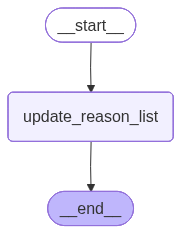

In [15]:
agent

In [55]:
shipment_order_reason_json[0]

Order(order_number='ORD1001', shipments=[Shipment(shipment_id='SHP2001', pickup_appointment=Timestamp('2026-05-02 09:00:00'), delivery_appointment=Timestamp('2026-05-04 16:00:00'), delete_time=None, reason_events=[ShipmentReasonEvent(reason_id=UUID('874ebc57-c0c1-40ad-aded-165e2a3cf935'), reason='Carrier Failure', tender_time=Timestamp('2026-05-01 08:15:00'), tender_response_time=Timestamp('2026-05-01 08:42:00')), ShipmentReasonEvent(reason_id=UUID('24eeb0bc-5b7a-46ec-a731-accc69a1b706'), reason='Spot over threshold', tender_time=Timestamp('2026-05-01 10:30:00'), tender_response_time=Timestamp('2026-05-01 10:48:00'))], invalid_reason_list=['24eeb0bc-5b7a-46ec-a731-accc69a1b706']), Shipment(shipment_id='SHP2002', pickup_appointment=Timestamp('2026-05-03 07:30:00'), delivery_appointment=Timestamp('2026-05-05 15:00:00'), delete_time=None, reason_events=[ShipmentReasonEvent(reason_id=UUID('09da9041-2dab-4d2e-8165-c5b5386da30a'), reason='Admin Planning', tender_time=Timestamp('2026-05-01 09

In [62]:
agent.invoke(shipment_order_reason_json[0])

{'order_number': 'ORD1001',
 'shipments': [Shipment(shipment_id='SHP2001', pickup_appointment=Timestamp('2026-05-02 09:00:00'), delivery_appointment=Timestamp('2026-05-04 16:00:00'), delete_time=None, reason_events=[ShipmentReasonEvent(reason_id=UUID('874ebc57-c0c1-40ad-aded-165e2a3cf935'), reason='Carrier Failure', tender_time=Timestamp('2026-05-01 08:15:00'), tender_response_time=Timestamp('2026-05-01 08:42:00')), ShipmentReasonEvent(reason_id=UUID('24eeb0bc-5b7a-46ec-a731-accc69a1b706'), reason='Spot over threshold', tender_time=Timestamp('2026-05-01 10:30:00'), tender_response_time=Timestamp('2026-05-01 10:48:00'))], invalid_reason_list=['24eeb0bc-5b7a-46ec-a731-accc69a1b706']),
  Shipment(shipment_id='SHP2002', pickup_appointment=Timestamp('2026-05-03 07:30:00'), delivery_appointment=Timestamp('2026-05-05 15:00:00'), delete_time=None, reason_events=[ShipmentReasonEvent(reason_id=UUID('09da9041-2dab-4d2e-8165-c5b5386da30a'), reason='Admin Planning', tender_time=Timestamp('2026-05-0